In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import string
import re

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
)
from torch.utils.data import Dataset, DataLoader

In [17]:
root_path = "/home/stefan/ioai-prep/kits/text_correct"
device = "cuda" if torch.cuda.is_available() else "cpu"

seed = 42
torch.random.manual_seed(seed)
random.seed(seed)

batch_size = 32

# Data

In [18]:
tokenizer = AutoTokenizer.from_pretrained("google-t5/t5-base")

df_train = pd.read_csv(f"{root_path}/train.csv")
df_test = pd.read_csv(f"{root_path}/test.csv")

In [19]:
df_train.head()

,SampleID,Text,RevisedText
0,747,She forgot her umbrella it started to rain.,"She forgot her umbrella, and then it started t..."
1,1382,He could have bought the house if he has enoug...,He could have bought the house if he had enoug...
2,241,I have a meeting with a principal of a school.,I have a meeting with the principal of the sch...
3,1647,26. You wanna grab some dinner later?,26. Do you want to have dinner later?
4,1461,The bicycle is more cheaper than the car.,The bicycle is cheaper than the car.


In [20]:
# Advanced Augmentation
def get_typo(char):
    # Approximate QWERTY layout neighbors
    keyboard = {
        "q": "w",
        "w": "qe",
        "e": "wr",
        "r": "et",
        "t": "ry",
        "y": "tu",
        "u": "yi",
        "i": "uo",
        "o": "ip",
        "p": "o",
        "a": "s",
        "s": "ad",
        "d": "sf",
        "f": "dg",
        "g": "fh",
        "h": "gj",
        "j": "hk",
        "k": "jl",
        "l": "k",
        "z": "x",
        "x": "zc",
        "c": "xv",
        "v": "cb",
        "b": "vn",
        "n": "bm",
        "m": "n",
    }
    char_lower = char.lower()
    if char_lower in keyboard:
        return random.choice(keyboard[char_lower])
    return char


def augment_text(text):
    """
    Simulates hasty typing:
    1. Skip random words (omission)
    2. Keyboard typos
    3. Remove punctuation
    4. Lowercase random words
    """
    words = text.split()
    if not words:
        return text

    # 1. Word Omission (p=0.15)
    if random.random() < 0.15 and len(words) > 3:
        remove_idx = random.randint(0, len(words) - 1)
        words.pop(remove_idx)

    # 2. Char Typos / Swap (p=0.15)
    if random.random() < 0.25:
        idx = random.randint(0, len(words) - 1)
        w = list(words[idx])
        if len(w) > 1:
            c_idx = random.randint(0, len(w) - 1)
            w[c_idx] = get_typo(w[c_idx])
            words[idx] = "".join(w)

    text = " ".join(words)

    # 3. Remove Punctuation (p=0.3)
    if random.random() < 0.3:
        text = text.translate(str.maketrans("", "", string.punctuation))

    # 4. Lowercase start (p=0.2)
    if random.random() < 0.2:
        text = text[0].lower() + text[1:] if text else text

    return text

In [21]:
class AutocorrectDataset(Dataset):
    def __init__(self, df: pd.DataFrame, is_train: bool):
        super().__init__()
        self.df = df
        self.is_train = is_train
        self.max_length = 128

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text_input = row["Text"]

        if self.is_train:
            text_input = augment_text(text_input)

        text = tokenizer(
            text_input, padding="max_length", truncation=True, max_length=128
        )

        if self.is_train:
            revised = tokenizer(
                row["RevisedText"],
                padding="max_length",
                truncation=True,
                max_length=128,
            )
            labels = torch.tensor(revised["input_ids"])
            labels[labels == tokenizer.pad_token_id] = -100

            return {
                "input_ids": torch.tensor(text["input_ids"]),
                "attention_mask": torch.tensor(text["attention_mask"]),
                "labels": labels,
            }

        return {
            "input_ids": torch.tensor(text["input_ids"]),
            "attention_mask": torch.tensor(text["attention_mask"]),
            "sample_id": row["SampleID"],
        }

    def __len__(self):
        return len(self.df)

In [22]:
train_full = AutocorrectDataset(df_train, is_train=True)
train_sz = int(0.8 * len(train_full))
val_sz = len(train_full) - train_sz
train_ds, val_ds = torch.utils.data.random_split(train_full, [train_sz, val_sz])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

test_ds = AutocorrectDataset(df_test, is_train=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [23]:
# sanity check
x = next(iter(train_loader))
{k: x[k].shape for k in x.keys()}

{'input_ids': torch.Size([32, 128]),
 'attention_mask': torch.Size([32, 128]),
 'labels': torch.Size([32, 128])}

# Model

In [24]:
model = AutoModelForSeq2SeqLM.from_pretrained("google-t5/t5-base").to(device)

In [25]:
model.config.dropout_rate = 0.5
model.config.classifier_dropout = 0.3

In [26]:
outputs = model(
    input_ids=x["input_ids"].to(device),
    attention_mask=x["attention_mask"].to(device),
    labels=x["labels"].to(device),
)
outputs.logits.shape

torch.Size([32, 128, 32128])

# Training

In [27]:
lr = 2e-4
epochs = 5

total_steps = len(train_loader) * epochs 
losses = []

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

In [28]:
for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0

    for batch in tqdm(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = model(**batch).loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item()
        losses.append(loss.item())

    model.eval()
    val_loss = 0.0

    for batch in tqdm(val_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.no_grad():
            loss = model(**batch).loss

        val_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    val_loss /= len(val_loader)

    print(f"Epoch {epoch}, loss={avg_loss:.2f}, val_loss={val_loss:.2f}")

100%|██████████| 11/11 [00:01<00:00,  6.81it/s]


Epoch 1, loss=0.54, val_loss=0.33


100%|██████████| 11/11 [00:01<00:00,  6.59it/s]


Epoch 2, loss=0.25, val_loss=0.26


100%|██████████| 11/11 [00:01<00:00,  6.68it/s]


Epoch 3, loss=0.19, val_loss=0.26


100%|██████████| 11/11 [00:01<00:00,  6.81it/s]


Epoch 4, loss=0.14, val_loss=0.27


100%|██████████| 11/11 [00:01<00:00,  6.71it/s]

Epoch 5, loss=0.11, val_loss=0.28


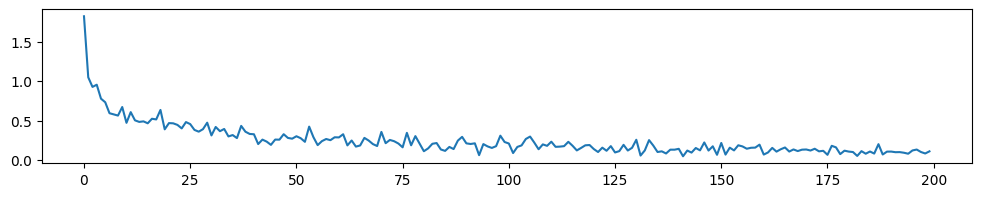

In [29]:
plt.figure(figsize=(12, 2))
plt.plot(losses)

# Submission

In [30]:
model.eval()
predictions = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        sample_ids = batch.pop("sample_id")
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model.generate(
            **batch,
            num_beams=5,
            repetition_penalty=1.5
        )
        texts = tokenizer.batch_decode(outputs, skip_special_tokens=True)

        for sid, text in zip(sample_ids, texts):
            predictions.append({"DatapointID": sid.item(), "RevisedText": text})

pd.DataFrame(predictions).to_csv(f"{root_path}/submission.csv", index=False)
print(f"Submission saved to {root_path}/submission.csv")

100%|██████████| 13/13 [00:05<00:00,  2.29it/s]

Submission saved to /home/stefan/ioai-prep/kits/text_correct/submission.csv
